In [1]:
import sys
import os
import warnings

sys.path.append(os.path.abspath("../scripts"))
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from data_loader import get_openml_data
from data_preprocessing import create_preprocessing_pipeline, preprocess_for_nn
from boosting_models import run_catboost_tuning, run_lgbm_tuning, run_lr_tuning
from deep_model import TabularDataset, TABMLP, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Bank](https://www.openml.org/search?type=data&id=1461&sort=runs&status=active)

In [2]:
dataset_id = 1461
X_train, X_valid, X_test, y_train, y_valid, y_test, categorical_indicator, attribute_names = get_openml_data(dataset_id)

In [3]:
column_transformer, categorical_features, numerical_features = create_preprocessing_pipeline(attribute_names, categorical_indicator)

In [4]:
model_lr = run_lr_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
metrics_lr = bootstrap_metrics(y_test, y_pred_lr, y_prob_lr)

[I 2025-04-21 16:27:22,285] A new study created in memory with name: logistic_regression_optimization
[I 2025-04-21 16:27:22,652] Trial 0 finished with value: 0.8985256334691571 and parameters: {'penalty': 'l2', 'C': 0.01}. Best is trial 0 with value: 0.8985256334691571.
[I 2025-04-21 16:27:22,817] Trial 1 finished with value: 0.8491722518187546 and parameters: {'penalty': 'l1', 'C': 0.001}. Best is trial 0 with value: 0.8985256334691571.
[I 2025-04-21 16:27:23,088] Trial 2 finished with value: 0.9005641725571734 and parameters: {'penalty': 'l2', 'C': 0.1}. Best is trial 2 with value: 0.9005641725571734.
[I 2025-04-21 16:27:23,197] Trial 3 finished with value: 0.5 and parameters: {'penalty': 'l1', 'C': 1e-05}. Best is trial 2 with value: 0.9005641725571734.
[I 2025-04-21 16:27:23,443] Trial 4 finished with value: 0.8985256334691571 and parameters: {'penalty': 'l2', 'C': 0.01}. Best is trial 2 with value: 0.9005641725571734.
[I 2025-04-21 16:27:23,708] Trial 5 finished with value: 0.900

In [5]:
model_cb = run_catboost_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_cb  = model_cb.predict(X_test)
y_prob_cb  = model_cb.predict_proba(X_test)[:, 1]
metrics_cb = bootstrap_metrics(y_test, y_pred_cb, y_prob_cb)

[I 2025-04-21 16:27:33,896] A new study created in memory with name: catboost_optimization
[I 2025-04-21 16:27:37,243] Trial 0 finished with value: 0.9321406980173716 and parameters: {'depth': 2, 'learning_rate': 0.1, 'l2_leaf_reg': 3.0}. Best is trial 0 with value: 0.9321406980173716.
[I 2025-04-21 16:27:45,421] Trial 1 finished with value: 0.9344590273053458 and parameters: {'depth': 8, 'learning_rate': 0.03, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.9344590273053458.
[I 2025-04-21 16:27:53,612] Trial 2 finished with value: 0.9206451554871309 and parameters: {'depth': 8, 'learning_rate': 0.3, 'l2_leaf_reg': 1.0}. Best is trial 1 with value: 0.9344590273053458.
[I 2025-04-21 16:27:57,653] Trial 3 finished with value: 0.9255904827777535 and parameters: {'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 0.001}. Best is trial 1 with value: 0.9344590273053458.
[I 2025-04-21 16:28:02,905] Trial 4 finished with value: 0.9007061980393855 and parameters: {'depth': 6, 'learning_rate':

In [6]:
model_lgbm = run_lgbm_tuning(X_train, y_train, X_valid, y_valid, column_transformer)
y_pred_lgbm = model_lgbm.predict(X_test)
y_prob_lgbm = model_lgbm.predict_proba(X_test)[:, 1]
metrics_lgbm = bootstrap_metrics(y_test, y_pred_lgbm, y_prob_lgbm)

[I 2025-04-21 16:29:55,978] A new study created in memory with name: lightgbm_optimization
[I 2025-04-21 16:30:01,180] Trial 0 finished with value: 0.924901659189025 and parameters: {'num_leaves': 64, 'reg_alpha': 1e-06, 'reg_lambda': 1.0, 'learning_rate': 0.3}. Best is trial 0 with value: 0.924901659189025.
[I 2025-04-21 16:31:04,116] Trial 1 finished with value: 0.9268341525836565 and parameters: {'num_leaves': 2048, 'reg_alpha': 1e-05, 'reg_lambda': 1e-05, 'learning_rate': 0.03}. Best is trial 1 with value: 0.9268341525836565.
[I 2025-04-21 16:31:04,929] Trial 2 finished with value: 0.9293740416238814 and parameters: {'num_leaves': 4, 'reg_alpha': 0.001, 'reg_lambda': 1e-06, 'learning_rate': 0.3}. Best is trial 2 with value: 0.9293740416238814.
[I 2025-04-21 16:31:05,759] Trial 3 finished with value: 0.92954731271218 and parameters: {'num_leaves': 4, 'reg_alpha': 1e-07, 'reg_lambda': 0.1, 'learning_rate': 0.3}. Best is trial 3 with value: 0.92954731271218.
[I 2025-04-21 16:31:21,615

In [7]:
X_train, X_valid, X_test = preprocess_for_nn(X_train, X_valid, X_test, categorical_features, numerical_features)

In [8]:
trainset = TabularDataset(X_train, y_train, categorical_features)
valset = TabularDataset(X_valid, y_valid, categorical_features)
testset  = TabularDataset(X_test, y_test, categorical_features)

batch_size = 256
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(valset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False)

In [9]:
cat_dims = [int(X_train[col].nunique()) for col in categorical_features]
emb_dims = [(x, min(50, (x + 1) // 2)) for x in cat_dims]

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


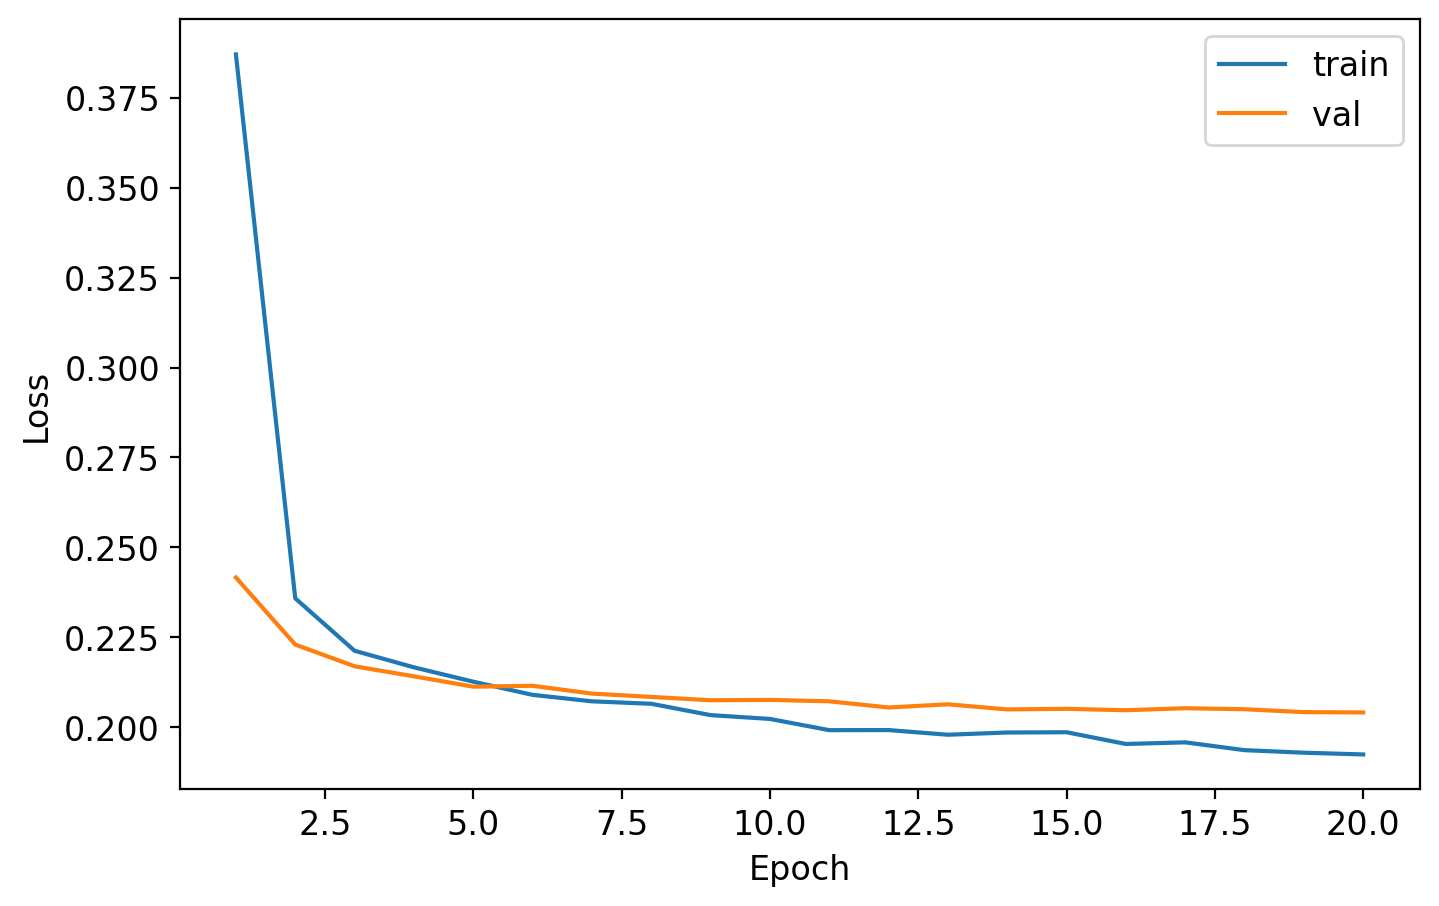

Epoch 20: train loss = 0.1924; valid loss = 0.2041


In [11]:
net = TABMLP(len(numerical_features), emb_dims).to(device)
optimizer = optim.Adam(net.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train(net, optimizer, 20, train_loader, val_loader, criterion, device)

In [12]:
y_true, y_prob, y_pred = evaluate(net, test_loader, device)
metrics_nn = bootstrap_metrics(y_true, y_pred, y_prob)

In [13]:
res = pd.DataFrame([{"model": "Logistic regression"} | metrics_lr, {"model": "CatBoost"} | metrics_cb, {"model": "LightGBM"} | metrics_lgbm, {"model": "TABMLP"} | metrics_nn])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,Logistic regression,0.9138±0.0059,0.4412±0.0214,0.9007±0.0044,0.6463±0.0290,0.3353±0.0198
1,CatBoost,0.9409±0.0040,0.5751±0.0184,0.9124±0.0041,0.6649±0.0235,0.5071±0.0205
2,LightGBM,0.9413±0.0038,0.5870±0.0186,0.9143±0.0041,0.6727±0.0230,0.5210±0.0210
3,TABMLP,0.9370±0.0043,0.6291±0.0175,0.9088±0.0044,0.6003±0.0208,0.6613±0.0206
